# 示例策略2: Alpha选股交易策略

本策略每隔1个月定时触发计算SHSE.000300成份股的过去的EV/EBITDA并选取EV/EBITDA大于0的股票，随后平掉排名EV/EBITDA不在最小的30的股票持仓并等权购买EV/EBITDA最小排名在前30的股票

回测数据为:SHSE.000300沪深300指数成份股

回测时间为:2016-04-05 到 2021-02-01

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.2.0, datasource: mysql://www.qteasy.cn@9306/ts_db


在选股之前，需要检查需要的历史数据

EV/EBITDA数据并不直接存在于qteasy定义的数据类型中，需要通过几个数据组合计算出来

$EV/EBITDA = {(MV + {Total Debt} - {Total Cash})}/ {EBITDA}$

上面几个数据分别代表:

- **MV**: 总市值
- **Total Debt**: 总负债
- **Total Cash**: 总现金及现金等价物
- **EBITDA**: 息税折旧摊销前利润

这些数据需要从qteasy内置的数据类型中分别提取，并使用上面的公式计算后，作为选股因子。排除掉小于0的因子后，将所有选股因子从小到大排列，选出因子排在最前的30支股票，将手中的全部资金平均分配投入到所有选中的股票中持有一个月，直到下一次选股为止。

In [2]:
from qteasy import DataType
mv = DataType('total_mv', asset_type='E')
debt = DataType('total_liab')
cash = DataType('c_cash_equ_end_period')
ebitda = DataType('ebitda')
print(mv, debt, cash, ebitda)

total_mv_E_d total_liab_E_q c_cash_equ_end_period_E_q ebitda_E_q


In [3]:
htypes = [mv, debt, cash, ebitda]
shares = qt.filter_stock_codes(index='000300.SH', date='20160101')
print(shares[0:50])
dt = qt.get_history_data(data_types=htypes, shares=shares, asset_type='ANY', freq='d')

['000001.SZ', '000002.SZ', '000063.SZ', '000069.SZ', '000100.SZ', '000157.SZ', '000166.SZ', '000333.SZ', '000338.SZ', '000413.SZ', '000415.SZ', '000423.SZ', '000425.SZ', '000538.SZ', '000568.SZ', '000596.SZ', '000625.SZ', '000627.SZ', '000629.SZ', '000630.SZ', '000651.SZ', '000656.SZ', '000661.SZ', '000671.SZ', '000703.SZ', '000709.SZ', '000723.SZ', '000725.SZ', '000728.SZ', '000768.SZ', '000776.SZ', '000783.SZ', '000786.SZ', '000858.SZ', '000876.SZ', '000895.SZ', '000898.SZ', '000938.SZ', '000961.SZ', '000963.SZ', '001979.SZ', '002001.SZ', '002007.SZ', '002008.SZ', '002010.SZ', '002024.SZ', '002027.SZ', '002032.SZ', '002044.SZ', '002050.SZ']


In [4]:

# print(type(dt), dt.keys())

In [5]:
share = shares[24]
df = dt[share]
df['ev_to_ebitda'] = (df.total_mv + df.total_liab - df.c_cash_equ_end_period) / df.ebitda

In [6]:
print(df.tail())

                total_mv  total_liab  c_cash_equ_end_period  ebitda  \
2026-03-06  4.665395e+06         NaN                    NaN     NaN   
2026-03-09  4.528496e+06         NaN                    NaN     NaN   
2026-03-10  4.287120e+06         NaN                    NaN     NaN   
2026-03-11  4.622164e+06         NaN                    NaN     NaN   
2026-03-12  4.496072e+06         NaN                    NaN     NaN   

            ev_to_ebitda  
2026-03-06           NaN  
2026-03-09           NaN  
2026-03-10           NaN  
2026-03-11           NaN  
2026-03-12           NaN  


## 第一种自定义策略设置方法: 使用持仓数据和选股数据直接生成比例交易信号PS信号：

使用GeneralStrategy策略类，计算选股因子后，去掉所有小于零的因子，排序后提取排名前三十的股票
按以下逻辑生成交易信号：
1，检查当前持仓，如果持仓的股票不在选中的30个中间，则全数卖出
2，检查当前持仓，如果新选中的股票没有持仓，则等权买入新增选中的股票

设置交易信号类型为PS，生成交易信号
由于生成交易信号需要用到持仓数据，因此不能使用批量生成模式，只能使用realtime模式

In [9]:
class AlphaPS(qt.GeneralStg):
    
    def realize(self):

        # 从历史数据编码中读取四种历史数据的最新数值
        total_mv = self.get_data('total_mv_E_d')[-1]  # 总市值
        total_liab = self.get_data('total_liab_E_q')[-1]  # 总负债
        cash_equ = self.get_data('c_cash_equ_end_period_E_q')[-1]  # 现金及现金等价物总额
        ebitda = self.get_data('ebitda_E_q')[-1]  # ebitda，息税折旧摊销前利润
        
        # 从持仓数据中读取当前的持仓数量，并找到持仓股序号
        own_amounts = self.get_data('proc.own_amounts')
        owned = np.where(own_amounts > 0)[0]  # 所有持仓股的序号
        not_owned = np.where(own_amounts == 0)[0]  # 所有未持仓的股票序号
        
        # 选股因子为EV/EBIDTA，使用下面公式计算
        factors = (total_mv + total_liab - cash_equ) / ebitda
        
        # 处理交易信号，将所有小于0的因子变为NaN
        factors = np.where(factors < 0, np.nan, factors)
        # print(f'got calculated factors: {factors}')
        # 选出数值最小的30个股票的序号
        arg_partitioned = factors.argpartition(30)
        selected = arg_partitioned[:30]  # 被选中的30个股票的序号
        not_selected = arg_partitioned[30:]  # 未被选中的其他股票的序号（包括因子为NaN的股票）
        
        # 开始生成交易信号
        signal = np.zeros_like(factors)
        signal[not_selected] = 0 
        
        # 如果持仓为零，且被选中，生成全仓买入交易信号
        signal[selected] = 0.0333
    
        return signal

定义好交易策略之后，就可以开始创建Operator对象并启动回测了：


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 0.0 ms
time consumption for operation back testing:  21.8 ms
investment starts on      2016-04-05 15:00:00
ends on                   2021-01-29 15:00:00
Total looped periods:     4.8 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000413.SZ     1       1       2    1.8%     -0.0%     98.2%  
000629.SZ     2       4       6    9.9%     -0.0%     90.1%  
000895.SZ     4       4       8   19.8%     -0.0%     80.2%  
002001.SZ     2       2       4   10.1%     -0.0%     89.9%  
002007.SZ     7       5      12   20.3%     -0.0%     79.7%  
002010.SZ     1       2       3    5.0%     -0.0%     95.0%  
002027.SZ     5       5   

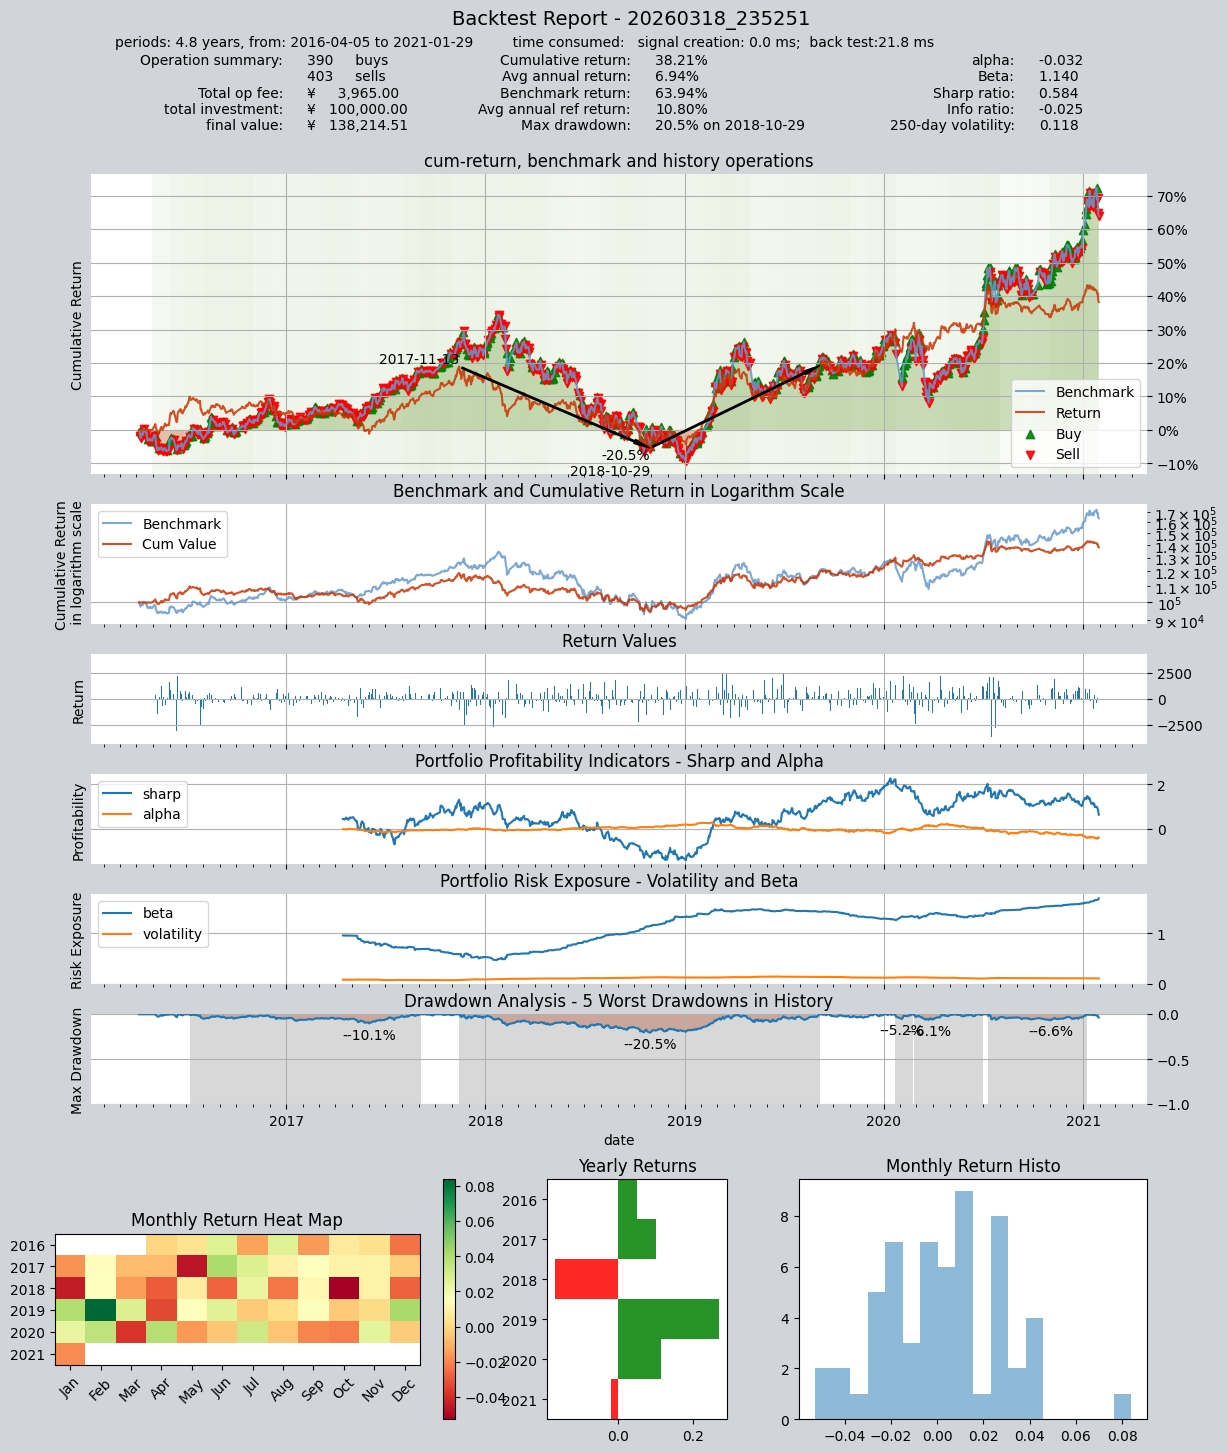

In [10]:
import numpy as np
alpha = AlphaPS(pars=[],
                 name='AlphaPS',
                 description='本策略每隔1个月定时触发计算SHSE.000300成份股的过去的EV/EBITDA并选取EV/EBITDA大于0的股票',
                 data_types=[DataType('total_mv', asset_type='E'),
                             DataType('total_liab'),
                             DataType('c_cash_equ_end_period'),
                             DataType('ebitda')],
                 window_length=10)  
op = qt.Operator(alpha, signal_type='PT', run_freq='ME')  # 每个月运行一次策略
qt.run(op=op,
       mode=1,
       asset_type='E',
       asset_pool=shares,
       invest_start='20160405',
       invest_end='20210201',
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True)
print()

## 第二种自定义策略设置方法：设置交易信号类型为PT，生成持仓目标信号，在回测过程中自动生成交易信号

In [11]:
class AlphaPT(qt.GeneralStg):
    
    def realize(self):

        # 从历史数据编码中读取四种历史数据的最新数值
        total_mv = self.get_data('total_mv_E_d')[-1]  # 总市值
        total_liab = self.get_data('total_liab_E_q')[-1]  # 总负债
        cash_equ = self.get_data('c_cash_equ_end_period_E_q')[-1]  # 现金及现金等价物总额
        ebitda = self.get_data('ebitda_E_q')[-1]  # ebitda，息税折旧摊销前利润
        
        # 选股因子为EV/EBIDTA，使用下面公式计算
        factors = (total_mv + total_liab - cash_equ) / ebitda
        # 处理交易信号，将所有小于0的因子变为NaN
        factors = np.where(factors < 0, np.nan, factors)
        # 选出数值最小的30个股票的序号
        arg_partitioned = factors.argpartition(30)
        selected = arg_partitioned[:30]  # 被选中的30个股票的序号，此时股票可能有NaN被选中的情况，需要去掉
        not_selected = arg_partitioned[30:]  # 未被选中的其他股票的序号（包括因子为NaN的股票）

        #如果选出的股票中有因子为NaN的，则剔除掉
        selected = selected[~np.isnan(selected)]
        sel_count = len(selected)
        
        # 开始生成PT交易信号
        signal = np.zeros_like(factors)
        # 所有被选中的股票的持仓目标被设置为0.03，表示持有3.3%
        signal[selected] = 1 / sel_count
        # 其余未选中的所有股票持仓目标在PT信号模式下被设置为0，代表目标仓位为0
        signal[not_selected] = 0  
        
        return signal
    

使用同样的方法创建一个Operator对象并启动回测。


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 3.6 ms
time consumption for operation back testing:  1.8 ms
investment starts on      2016-04-05 15:00:00
ends on                   2021-01-29 15:00:00
Total looped periods:     4.8 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000413.SZ     1       1       2    1.8%     -0.0%     98.2%  
000629.SZ     2       4       6    9.9%     -0.0%     90.1%  
000895.SZ     4       4       8   19.8%     -0.0%     80.2%  
002001.SZ     2       2       4   10.1%     -0.0%     89.9%  
002007.SZ     7       5      12   20.3%     -0.0%     79.7%  
002010.SZ     1       2       3    5.0%     -0.0%     95.0%  
002027.SZ     5       5    

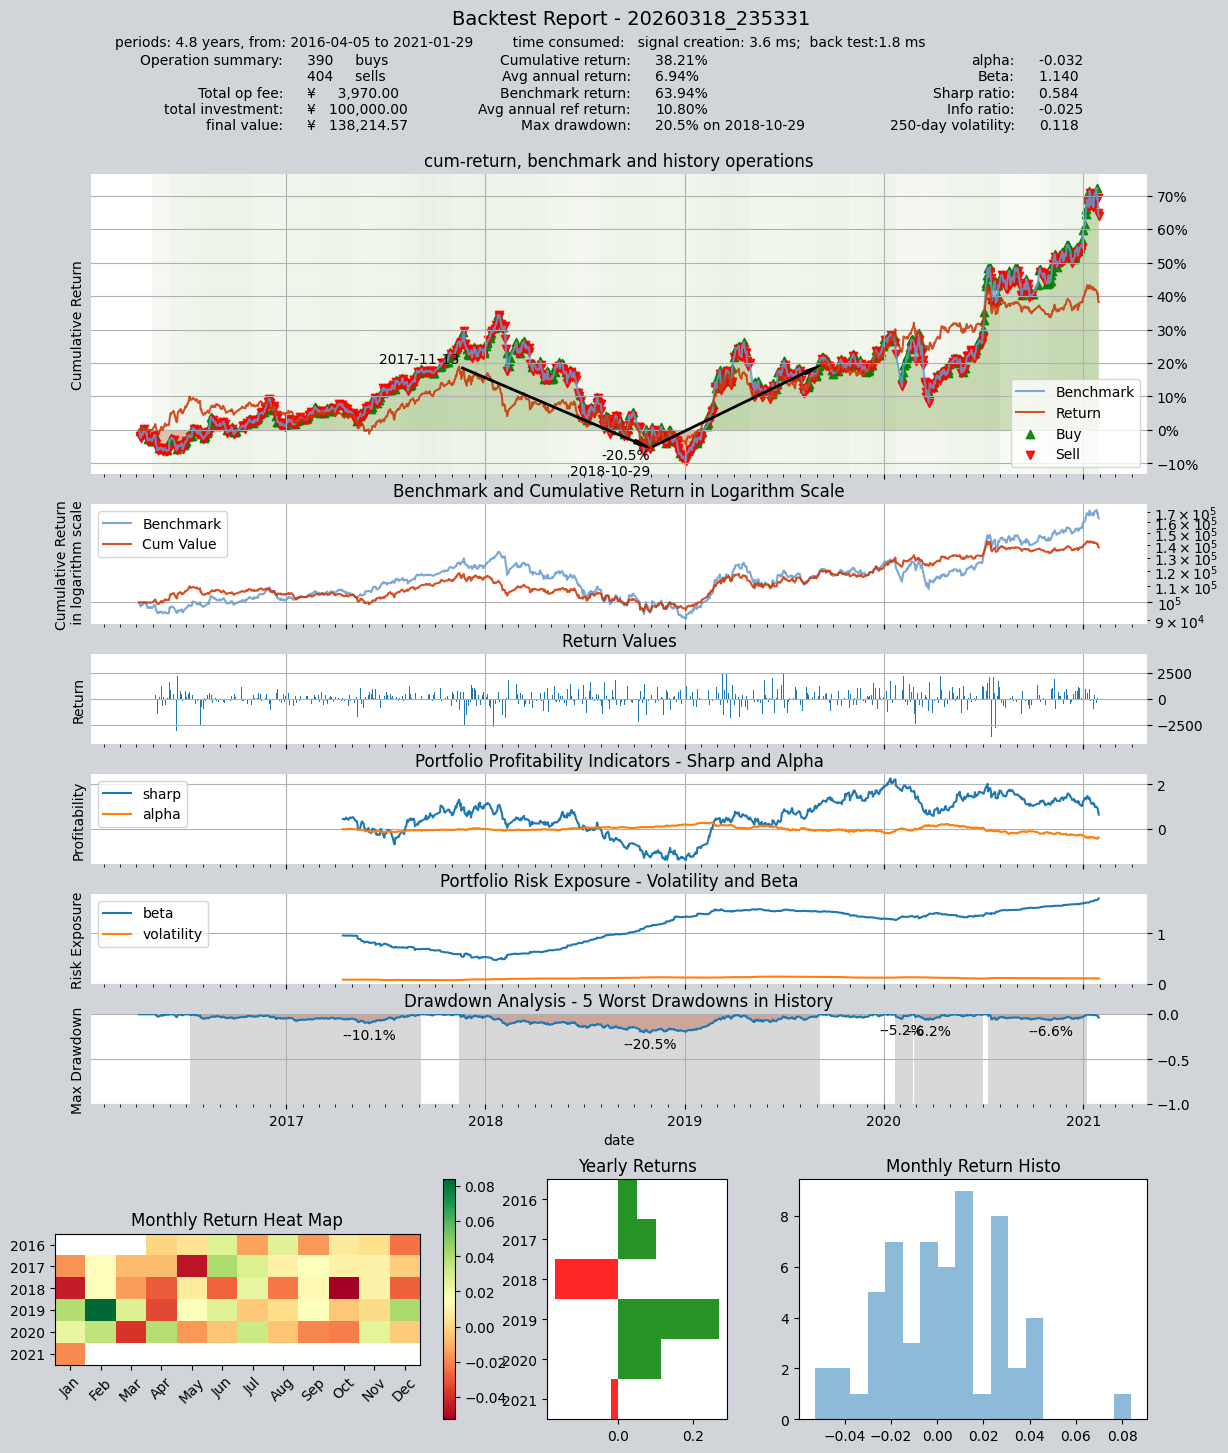

In [13]:
import numpy as np
alpha = AlphaPT(pars=(),
                 name='AlphaSel',
                 description='本策略每隔1个月定时触发计算SHSE.000300成份股的过去的EV/EBITDA并选取EV/EBITDA大于0的股票',
                 data_types=[DataType('total_mv', asset_type='E'),
                             DataType('total_liab'),
                             DataType('c_cash_equ_end_period'),
                             DataType('ebitda')],
                 window_length=10)  
op = qt.Operator(alpha, signal_type='PT', run_freq='ME')
res = qt.run(op=op, 
             mode=1,
             asset_type='E',
             asset_pool=shares,
             invest_start='20160405',
             invest_end='20210201',
             PT_buy_threshold=0.00,  # 如果设置PBT=0.00，PST=0.03，最终收益会达到30万元
             PT_sell_threshold=0.00,
             trade_batch_size=100,
             sell_batch_size=1,
             trade_log=True
            )

## 第三种自定义策略设置方法：使用FactorSorter策略类
使用FactorSorter策略类，直接生成交易策略的选股因子，再根据
FactorSorter策略的选股参数实现选股

设置交易信号类型为PT，生成持仓目标，自动生成交易信号

In [14]:
class AlphaFac(qt.FactorSorter):
    
    def realize(self):

        # 从历史数据编码中读取四种历史数据的最新数值
        total_mv = self.get_data('total_mv_E_d')[-1]  # 总市值
        total_liab = self.get_data('total_liab_E_q')[-1]  # 总负债
        cash_equ = self.get_data('c_cash_equ_end_period_E_q')[-1]  # 现金及现金等价物总额
        ebitda = self.get_data('ebitda_E_q')[-1]  # ebitda，息税折旧摊销前利润
        
        # 选股因子为EV/EBIDTA，使用下面公式计算
        factor = (total_mv + total_liab - cash_equ) / ebitda

        # 由于使用因子排序选股策略，因此直接返回选股因子即可，策略会自动根据设置条件选股
        return factor
    

使用同样的方法创建一个Operator对象并启动回测。


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 4.4 ms
time consumption for operation back testing:  1.6 ms
investment starts on      2016-04-05 15:00:00
ends on                   2021-01-29 15:00:00
Total looped periods:     4.8 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000413.SZ     1        1      2    1.8%     -0.0%     98.2%  
000423.SZ     9       12     21   29.8%     -0.0%     70.2%  
000538.SZ    -0        1      1    0.1%     -0.0%     99.9%  
000568.SZ     2        2      4    5.1%     -0.0%     94.9%  
000596.SZ     4        6     10   15.4%     -0.0%     84.6%  
000629.SZ     2        6      8    9.9%     -0.0%     90.1%  
000661.SZ     5        7   

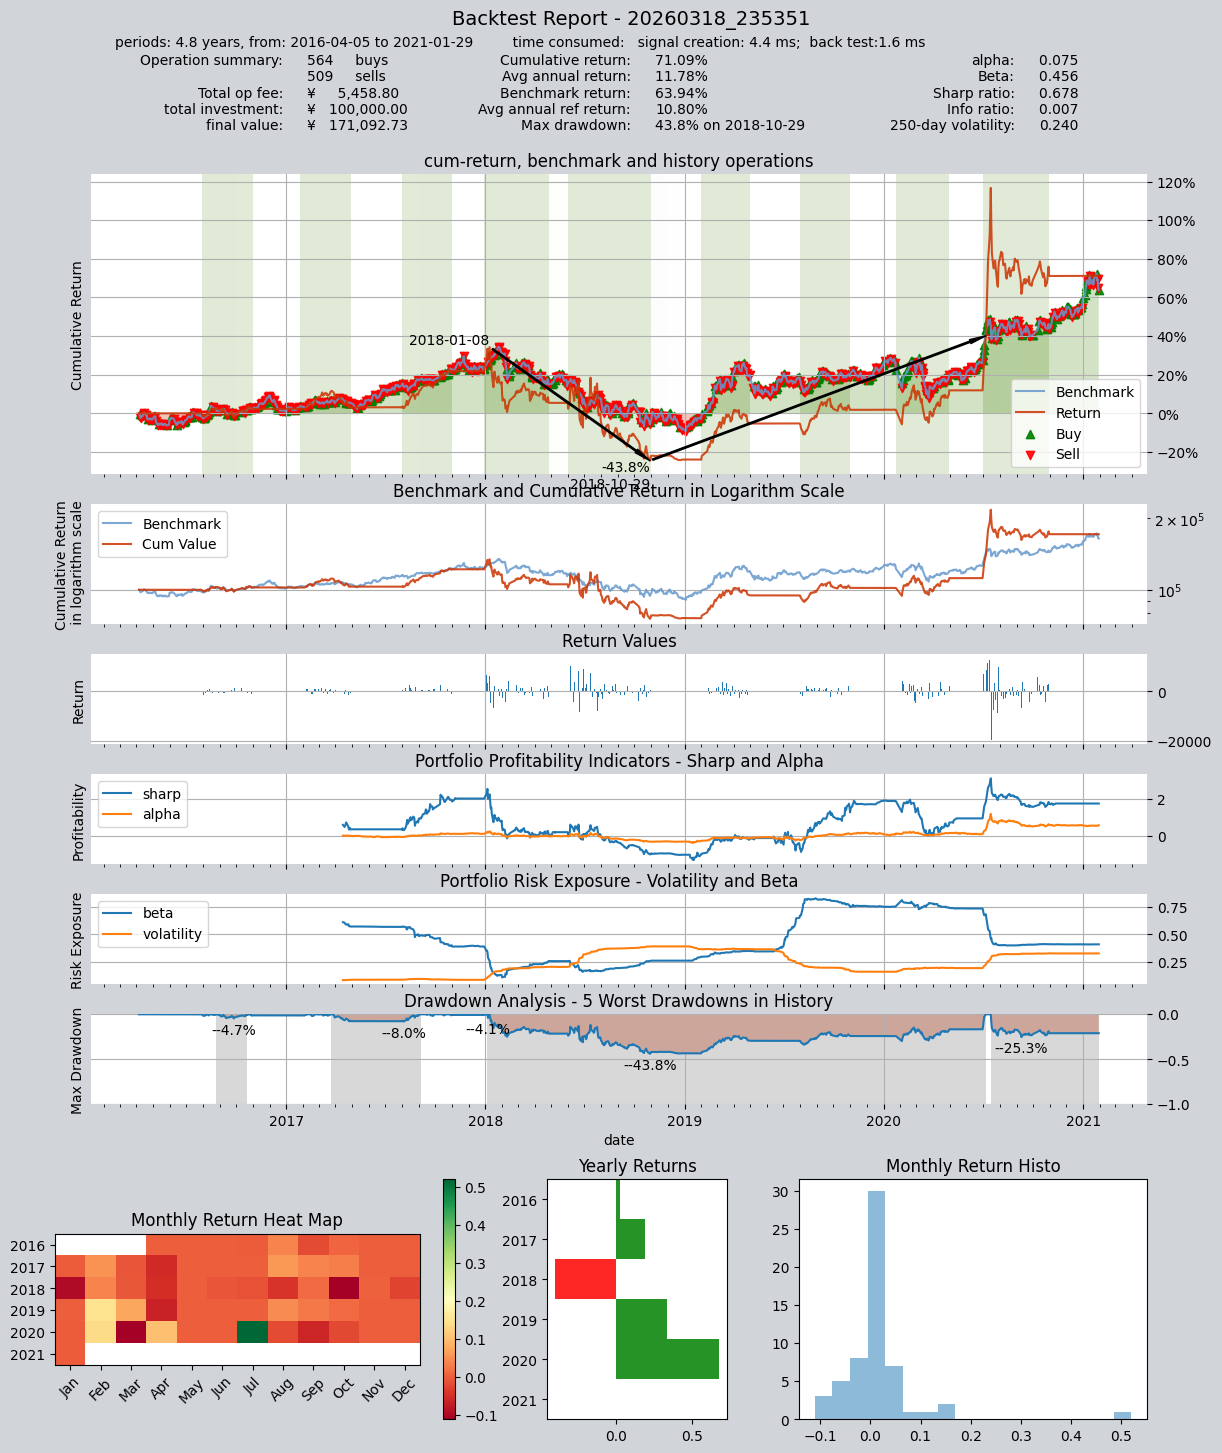

In [15]:
alpha = AlphaFac(pars=(),
                 name='AlphaSel',
                 description='本策略每隔1个月定时触发计算SHSE.000300成份股的过去的EV/EBITDA并选取EV/EBITDA大于0的股票',
                 data_types=[DataType('total_mv', asset_type='E'),
                             DataType('total_liab'),
                             DataType('c_cash_equ_end_period'),
                             DataType('ebitda')],
                 window_length=10,  
                 max_sel_count=30,  # 设置选股数量，最多选出30个股票
                 condition='greater',  # 设置筛选条件，仅筛选因子大于ubound的股票
                 ubound=0.0,  # 设置筛选条件，仅筛选因子大于0的股票
                 weighting='even',  # 设置股票权重，所有选中的股票平均分配权重
                 sort_ascending=True)  # 设置排序方式，因子从小到大排序选择头30名
op = qt.Operator(alpha, signal_type='PT', run_freq='ME')
res = qt.run(op=op, 
             mode=1,
             asset_type='E',
             asset_pool=shares,
             invest_start='20160405',
             invest_end='20210201',
             PT_buy_threshold=0.00,  # 如果设置PBT=0.00，PST=0.03，最终收益会达到30万元
             PT_sell_threshold=0.00,
             trade_batch_size=1,
             sell_batch_size=1,
             trade_log=True
            )


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 12.4 ms
time consumption for operation back testing:  0.6 ms
investment starts on      2011-01-04 15:00:00
ends on                   2017-07-06 15:00:00
Total looped periods:     6.5 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000651.SZ    5        5      10   20.8%     -0.0%     79.2%  
000001.SZ    9        9      18   19.7%     -0.0%     80.3%  

Total operation fee:     ¥      823.77
total investment amount: ¥  100,000.00
final value:              ¥  229,761.88
Total return:                   129.76% 
Avg Yearly return:               13.64%
Skewness:                          1.79
Kurtosis:                         

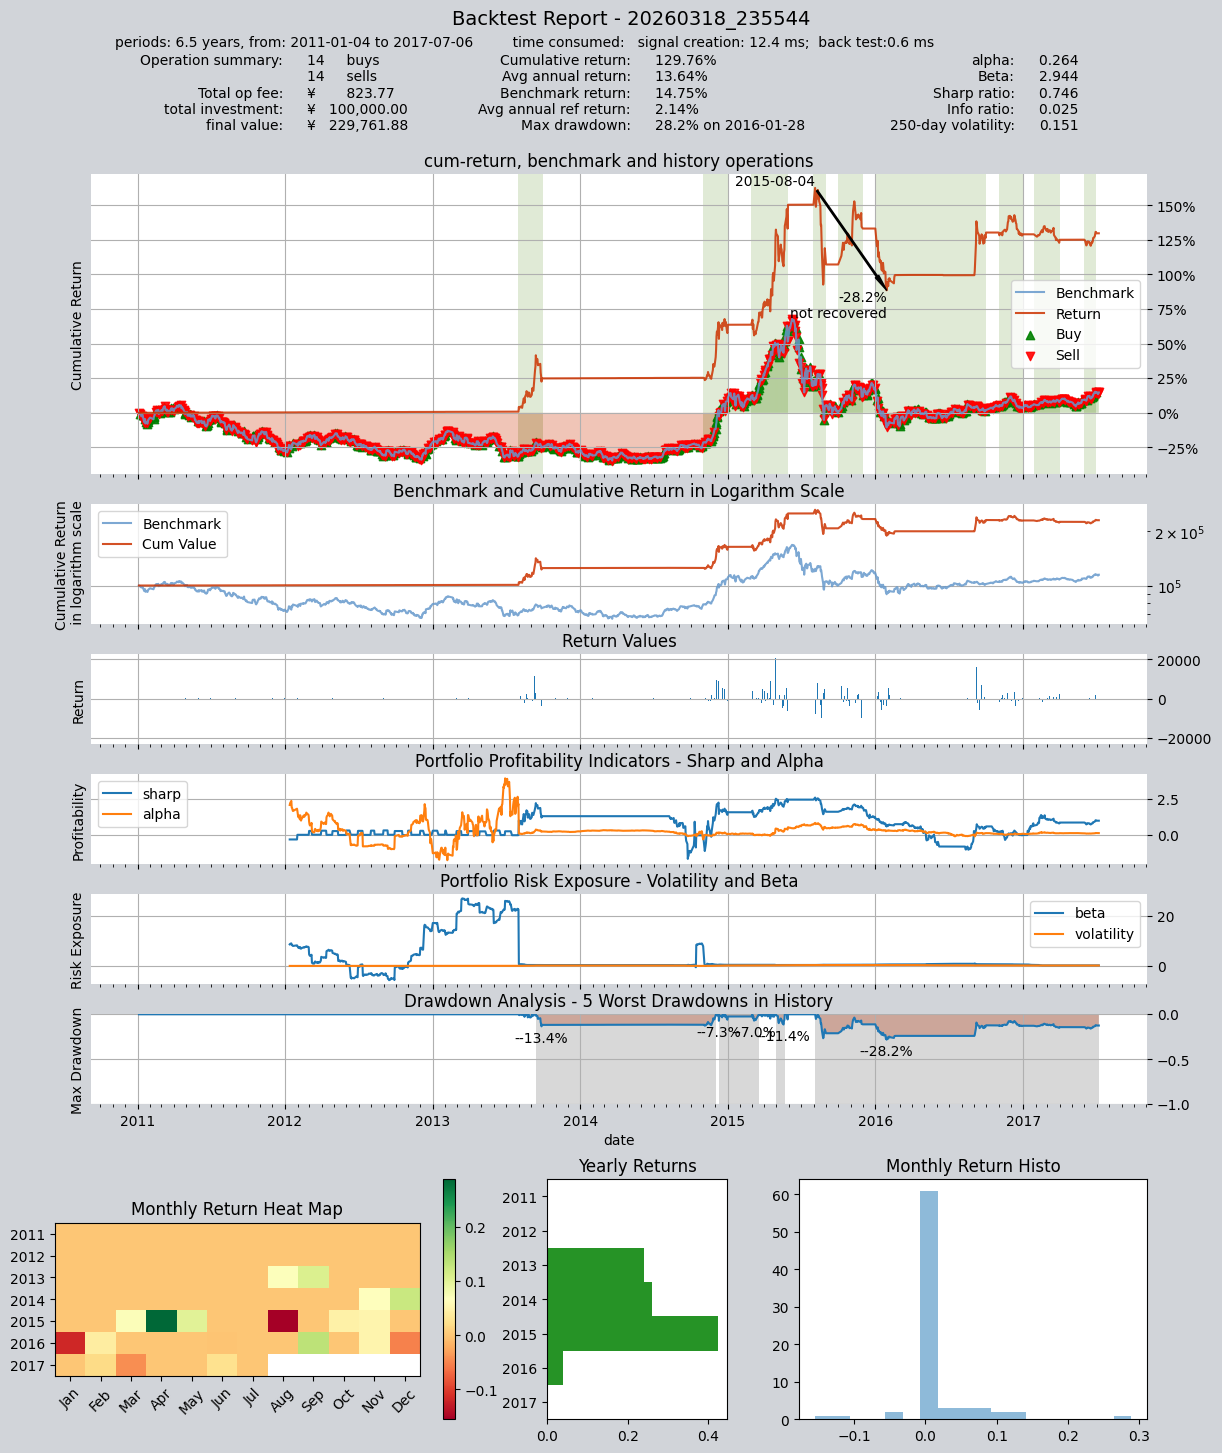

In [16]:
op_test = qt.Operator('dma',run_freq='ME')
res = qt.run(op=op_test, 
             mode=1,
             asset_type='E',
             asset_pool=['000651.SZ', '000001.SZ'],
             invest_start='20110101',
             invest_end='20170707',
             PT_buy_threshold=0.00,  # 如果设置PBT=0.00，PST=0.03，最终收益会达到30万元
             PT_sell_threshold=0.00,
             trade_batch_size=100,
             sell_batch_size=1,
             trade_log=True
            )

In [8]:
print(res.keys())

dict_keys(['final_value', 'backtest_start', 'backtest_end', 'complete_values', 'days', 'months', 'years', 'oper_count', 'total_invest', 'total_fee', 'rtn', 'annual_rtn', 'skew', 'kurtosis', 'return_df', 'mdd', 'peak_date', 'valley_date', 'recover_date', 'worst_drawdowns', 'volatility', 'benchmark_rtn', 'benchmark_a_rtn', 'beta', 'sharp', 'alpha', 'info', 'op_run_time', 'loop_run_time', 'trade_log', 'trade_summary', 'report'])


In [9]:
res['complete_values']

,000651.SZ,000001.SZ,cash,value,fee,invest,underwater,volatility,benchmark,pct_change,beta,sharp,alpha
2011-01-04 15:00:00,0.0,0.0,100000.000,100000.000,0.0,100000,0.000000,NaN,3189.68,NaN,NaN,NaN,NaN
2011-01-05 15:00:00,0.0,0.0,100000.000,100000.000,0.0,0,0.000000,NaN,3175.66,0.000000,NaN,NaN,NaN
2011-01-06 15:00:00,0.0,0.0,100000.000,100000.000,0.0,0,0.000000,NaN,3159.64,0.000000,NaN,NaN,NaN
2011-01-07 15:00:00,0.0,0.0,100000.000,100000.000,0.0,0,0.000000,NaN,3166.62,0.000000,NaN,NaN,NaN
2011-01-10 15:00:00,0.0,0.0,100000.000,100000.000,0.0,0,0.000000,NaN,3108.19,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-30 15:00:00,0.0,0.0,229010.451,229010.451,0.0,0,-0.153763,0.122825,3666.80,-0.004324,0.377945,0.635184,0.006533
2017-07-03 15:00:00,0.0,0.0,229010.451,229010.451,0.0,0,-0.153763,0.122069,3650.85,0.000000,0.375202,0.525399,-0.001911
2017-07-04 15:00:00,0.0,0.0,229010.451,229010.451,0.0,0,-0.153763,0.121787,3619.98,0.000000,0.373790,0.592192,0.008246
2017-07-05 15:00:00,0.0,0.0,229010.451,229010.451,0.0,0,-0.153763,0.121317,3659.68,0.000000,0.366598,0.679812,0.010294
